In [3]:
import cv2
import pandas as pd
from glob import glob
from scipy.io import wavfile
import re
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import math

In [4]:
exps = [433,436,437]

In [5]:
# Functions to sort file names correctly
def atoi(text):
    return int(text) if text.isdigit() else text

def natural_keys(text):
    return [ atoi(c) for c in re.split(r'(\d+)', text) ]

In [6]:
# Getting the CSV's of both das and sleap
das = {}
slp = {}
videos = {}
headmic = {}

for exp_no in exps:
    
    path = f"D:/big_setup/experiment_{exp_no}/concatenated_data_cam_mic_sync/ssl_data_path/*/"
    temp = glob(path + "headmic*.wav")
    temp.sort(key=natural_keys)
    headmic[exp_no] = temp

    temp =  glob(path + "video*.mp4")
    temp.sort(key=natural_keys)
    videos[exp_no] = temp

    temp =  glob(path + "labels*.csv")
    temp.sort(key=natural_keys)
    slp[exp_no] = temp

    temp = glob(path + "*headmic*.csv")
    temp.sort(key=natural_keys)
    das[exp_no] = temp 

### Ratio between number of calls from each animal for each experiment

In [7]:
vox_per_animal = {}

for exp_no in exps:
    total_counts = None
    
    for das_file in das[exp_no]:
        vox_times = pd.read_csv(das_file)
        vox_rows = vox_times[vox_times["name"] == "vox"]
        counts = vox_rows["label"].value_counts()
        
        if total_counts is None:
            total_counts = counts
        else:
            total_counts = total_counts.add(counts, fill_value=0)
    
    vox_per_animal[exp_no] = total_counts.fillna(0).astype(int)

C:\Users\DAQ3\AppData\Local\Temp\ipykernel_33888\3852966229.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab20', len(all_labels))


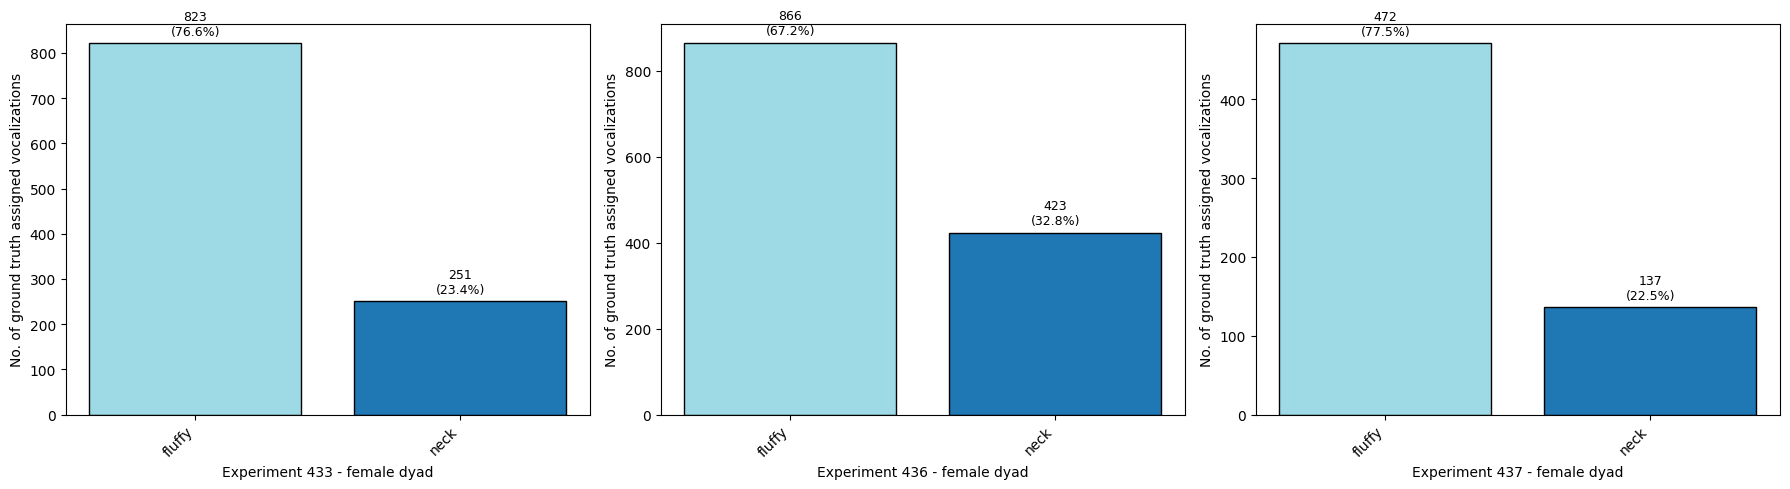

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Example label mapping: numeric → name
label_map = {
    118.0: "fluffy",
    35.0: "neck",
    # Add all your label mappings here
}

# Get all unique labels across experiments
all_labels = set()
for counts in vox_per_animal.values():
    all_labels.update(counts.index)
all_labels = sorted(all_labels)  # sort to keep consistent order

# Assign a color to each label (same color across experiments)
import matplotlib.cm as cm
import numpy as np
color_map = cm.get_cmap('tab20', len(all_labels))
label_colors = {label: color_map(i) for i, label in enumerate(all_labels)}

n = len(vox_per_animal)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=False)

if n == 1:
    axes = [axes]

for ax, (exp_no, counts) in zip(axes, vox_per_animal.items()):
    counts = counts.sort_values(ascending=False)
    total = counts.sum()
    
    # Map numeric labels to names for plotting
    labels = [label_map.get(l, str(l)) for l in counts.index]
    
    # Assign colors based on label
    colors = [label_colors[l] for l in counts.index]
    
    bars = ax.bar(range(len(counts)), counts.values,
                  color=colors, edgecolor='black')
    
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    
    # ax.set_title(f"Experiment {exp_no}")
    ax.set_xlabel(f"Experiment {exp_no} - female dyad")
    ax.set_ylabel("No. of ground truth assigned vocalizations")
    
    # Add count + ratio labels on top
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ratio = height / total
        ax.text(bar.get_x() + bar.get_width()/2,
                height + total*0.01,
                f"{int(height)}\n({ratio:.1%})",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Animal occupancy plots

In [9]:
# nested dict: exp_no → animal_id → list of positions
head_position_per_animal = defaultdict(lambda: defaultdict(list))

cam_fps = 29.997600192

for exp_no in exps:
    for das_file in das[exp_no]:

        # match SLEAP file
        slp_file = [j for j in slp[exp_no] if das_file.split("\\")[1] in j][0]

        track_points = pd.read_csv(slp_file)
        vox_times = pd.read_csv(das_file)

        # ✅ clean columns ONCE
        track_points.columns = track_points.columns.str.replace(".", "_", regex=False)

        vox_rows = vox_times[vox_times["name"] == "vox"]

        for vox_idx, start, stop in zip(
            vox_rows.index,
            vox_rows.start_seconds,
            vox_rows.stop_seconds
        ):
            if math.isnan(start) or math.isnan(stop):
                continue

            start_frame = int(start * cam_fps)
            stop_frame = int(stop * cam_fps)

            for frame in range(start_frame, stop_frame + 1):
                temp_df = track_points[track_points["frame_idx"] == frame]

                for row in temp_df.itertuples(index=False):
                    # extract animal ID safely
                    try:
                        animal_id = row.track.split("_")[1]
                    except Exception:
                        continue

                    head_position_per_animal[exp_no][animal_id].append(
                        (row.head_x, row.head_y)
                    )

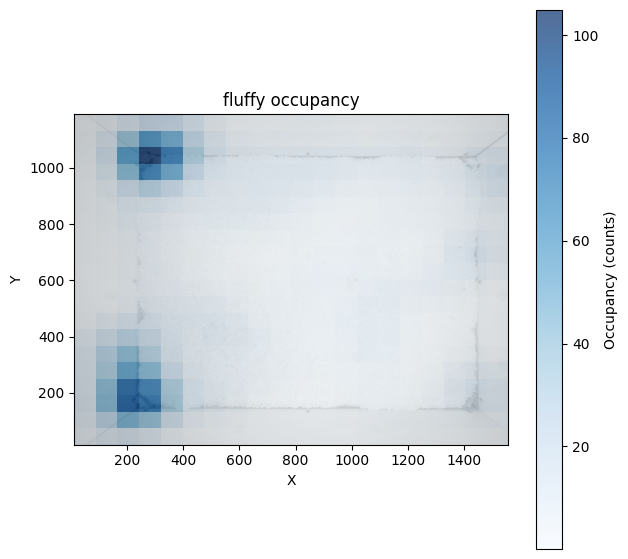

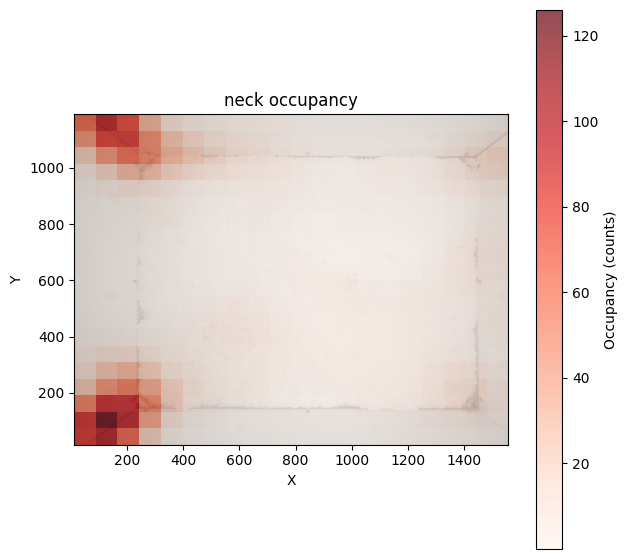

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import matplotlib.image as mpimg

# load background image
img = mpimg.imread("arena.png")
exp_no = 436

animals = list(head_position_per_animal[exp_no].keys())[:2]

pos1 = head_position_per_animal[exp_no][animals[0]]
pos2 = head_position_per_animal[exp_no][animals[1]]

x1, y1 = zip(*pos1)
x2, y2 = zip(*pos2)

# shared spatial bounds
x_min = min(min(x1), min(x2))
x_max = max(max(x1), max(x2))
y_min = min(min(y1), min(y2))
y_max = max(max(y1), max(y2))

bins = 20

# compute heatmaps
heat1, xedges, yedges = np.histogram2d(
    x1, y1, bins=bins, range=[[x_min, x_max], [y_min, y_max]]
)
heat2, _, _ = np.histogram2d(
    x2, y2, bins=bins, range=[[x_min, x_max], [y_min, y_max]]
)

# smooth + normalize
heat1 = gaussian_filter(heat1, sigma=1)
heat2 = gaussian_filter(heat2, sigma=1)

# heat1 /= heat1.max()
# heat2 /= heat2.max()

# ---- PLOT 1: Animal 1 ----
plt.figure(figsize=(7, 7))

plt.imshow(img, extent=[x_min, x_max, y_min, y_max], origin='lower')

im1 = plt.imshow(
    heat1.T,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='Blues',
    alpha=0.7
)

plt.colorbar(im1, label="Occupancy (counts)")

label_map = {
    "118": "fluffy",
    "35": "neck",
    # Add all your label mappings here
}

plt.title(f"{label_map[animals[0]]} occupancy")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()


# ---- PLOT 2: Animal 2 ----
plt.figure(figsize=(7, 7))

plt.imshow(img, extent=[x_min, x_max, y_min, y_max], origin='lower')

im2 = plt.imshow(
    heat2.T,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='Reds',
    alpha=0.7
)

plt.colorbar(im2, label="Occupancy (counts)")

plt.title(f"{label_map[animals[1]]} occupancy")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

### Animal distances vs number of vocalizations

In [11]:
import cv2
import numpy as np

def pixel_to_world(u, v, cameraMatrix, distCoeffs, rvec, tvec):
    # undistort the point
    pts = np.array([[[u, v]]], dtype=np.float32)
    undistorted = cv2.undistortPoints(pts, cameraMatrix, distCoeffs)

    # convert to normalized camera coordinates
    x = undistorted[0, 0, 0]
    y = undistorted[0, 0, 1]

    # direction vector in camera frame
    ray_cam = np.array([x, y, 1.0])


    # rotation matrix
    R = rvec

    # transform ray into world coordinates
    ray_world = R.T @ ray_cam
    cam_center = -R.T @ tvec.reshape(3)

    if abs(ray_world[2]) < 1e-6:
     return None, None

    # find intersection with Z=0 plane
    s = -cam_center[2] / ray_world[2]
    world_point = cam_center + s * ray_world

    return world_point[0], world_point[1]  # X, Y only

In [12]:
import math
from collections import defaultdict


camera_calibration_exp = 306

cameraMatrix = np.load(f"D:/sleap-3D/session_{camera_calibration_exp}/camera_matrix.npy")
distCoeffs = np.load(f"D:/sleap-3D/session_{camera_calibration_exp}/dist_coeffs.npy")


# rotation and translation matrix from world to camera coordinate system
rvec = np.load(f"D:/sleap-3D/session_{camera_calibration_exp}/cam_rotation.npy")
tvec = np.load(f"D:/sleap-3D/session_{camera_calibration_exp}/cam_translation.npy")

# Fix defaultdict structure for distances (list per experiment)
head_distance_between_animals = defaultdict(list)
head_distance_pixels = defaultdict(list)

for exp_no in exps:
    for das_file in das[exp_no]:

        # match SLEAP file
        slp_file = [j for j in slp[exp_no] if das_file.split("\\")[1] in j][0]

        track_points = pd.read_csv(slp_file)
        vox_times = pd.read_csv(das_file)

        track_points.columns = track_points.columns.str.replace(".", "_", regex=False)

        vox_rows = vox_times[vox_times["name"] == "vox"]

        for vox_idx, start, stop in zip(
            vox_rows.index,
            vox_rows.start_seconds,
            vox_rows.stop_seconds
        ):
            if math.isnan(start) or math.isnan(stop):
                continue

            start_frame = int(start * cam_fps)
            stop_frame = int(stop * cam_fps)

            for frame in range(start_frame, stop_frame + 1):
                temp_df = track_points[track_points["frame_idx"] == frame]

                if len(temp_df) == 2:
                    points_world = []
                    points_pixel = []

                    for row in temp_df.itertuples(index=False):
                        u, v = row.head_x, row.head_y

                        # store pixel coords
                        points_pixel.append((u, v))

                        # convert to world
                        Xw, Yw = pixel_to_world(u, v, cameraMatrix, distCoeffs, rvec, tvec)
                        points_world.append((Xw, Yw))

                    # unpack
                    (x1, y1), (x2, y2) = points_world
                    (u1, v1), (u2, v2) = points_pixel

                    # world distance
                    dist_world = math.hypot(x1 - x2, y1 - y2)

                    # pixel distance
                    dist_pixel = math.hypot(u1 - u2, v1 - v2)

                    # store both
                    head_distance_between_animals[exp_no].append(dist_world)
                    head_distance_pixels[exp_no].append(dist_pixel)


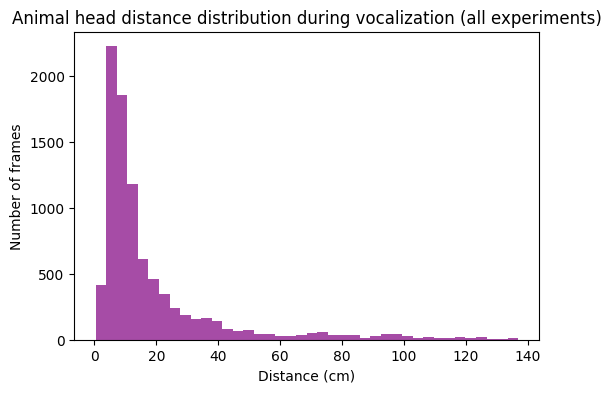

In [13]:
# combine all experiments
all_distances_m = []

for exp_no in head_distance_between_animals:
    all_distances_m.extend(head_distance_between_animals[exp_no])

# convert to mm
all_distances_mm = np.array(all_distances_m) * 100

# plot
plt.figure(figsize=(6,4))

plt.hist(all_distances_mm, bins=40, color='purple', alpha=0.7)

plt.xlabel("Distance (cm)")
plt.ylabel("Number of frames")
plt.title("Animal head distance distribution during vocalization (all experiments)")

plt.show()

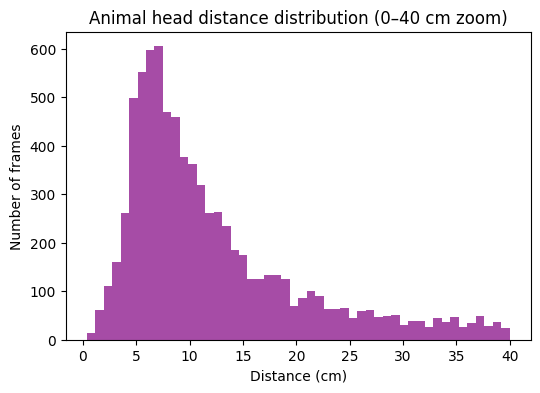

In [14]:
# focus on close distances
close_distances = all_distances_mm[all_distances_mm <= 40]

plt.figure(figsize=(6,4))

plt.hist(close_distances, bins=50, color='purple', alpha=0.7)

plt.xlabel("Distance (cm)")
plt.ylabel("Number of frames")
plt.title("Animal head distance distribution (0–40 cm zoom)")

plt.show()

### Verifying the distances

In [15]:
import math
from collections import defaultdict


camera_calibration_exp = 306

cameraMatrix = np.load(f"D:/sleap-3D/session_{camera_calibration_exp}/camera_matrix.npy")
distCoeffs = np.load(f"D:/sleap-3D/session_{camera_calibration_exp}/dist_coeffs.npy")


# rotation and translation matrix from world to camera coordinate system
rvec = np.load(f"D:/sleap-3D/session_{camera_calibration_exp}/cam_rotation.npy")
tvec = np.load(f"D:/sleap-3D/session_{camera_calibration_exp}/cam_translation.npy")

# new structure
frame_samples = defaultdict(list)

for exp_no in exps:
    for das_file in das[exp_no]:

        # match SLEAP file
        slp_file = [j for j in slp[exp_no] if das_file.split("\\")[1] in j][0]

        # match vid file
        vid_file = [j for j in videos[exp_no] if das_file.split("\\")[1] in j][0]

        track_points = pd.read_csv(slp_file)
        vox_times = pd.read_csv(das_file)

        track_points.columns = track_points.columns.str.replace(".", "_", regex=False)

        vox_rows = vox_times[vox_times["name"] == "vox"]

        for vox_idx, start, stop in zip(
            vox_rows.index,
            vox_rows.start_seconds,
            vox_rows.stop_seconds
        ):
            if math.isnan(start) or math.isnan(stop):
                continue

            start_frame = int(start * cam_fps)
            stop_frame = int(stop * cam_fps)

            for frame in range(start_frame, stop_frame + 1):
                temp_df = track_points[track_points["frame_idx"] == frame]


                if len(temp_df) == 2:
                    points_world = []
                    points_pixel = []

                    for row in temp_df.itertuples(index=False):
                        u, v = row.head_x, row.head_y
                        points_pixel.append((u, v))

                        Xw, Yw = pixel_to_world(u, v, cameraMatrix, distCoeffs, rvec, tvec)
                        points_world.append((Xw, Yw))

                    (x1, y1), (x2, y2) = points_world
                    (u1, v1), (u2, v2) = points_pixel

                    dist_world = math.hypot(x1 - x2, y1 - y2)

                    # store everything
                    frame_samples[exp_no].append({
                        "frame": frame,
                        "vid": vid_file,
                        "dist": dist_world,
                        "u1": u1, "v1": v1,
                        "u2": u2, "v2": v2,
                        "slp_file": slp_file   # useful for reloading context
    })


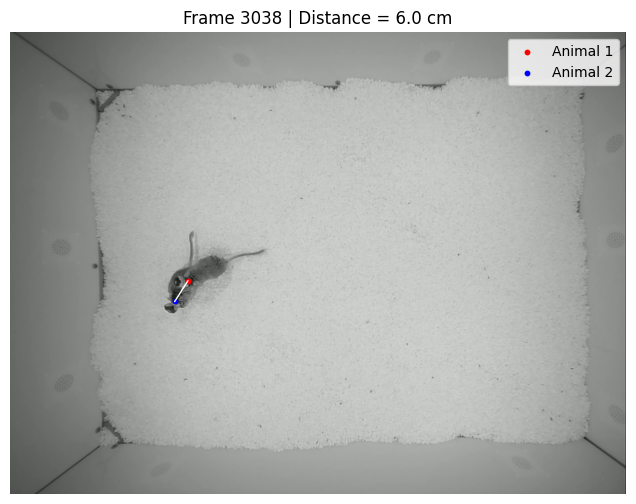

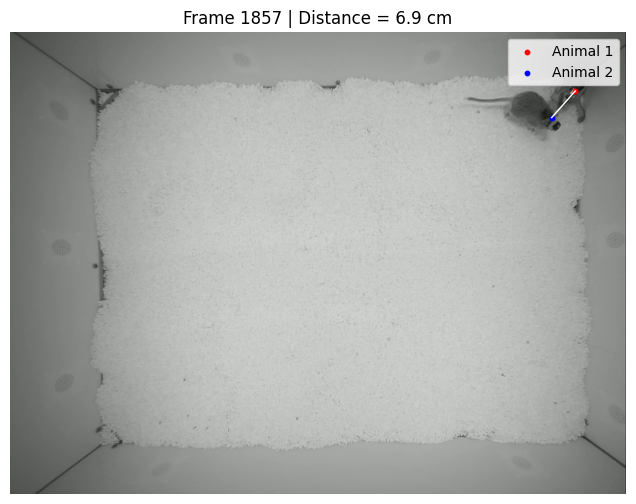

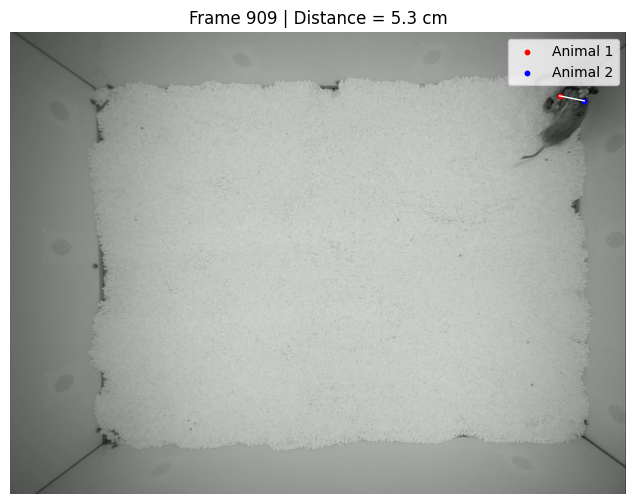

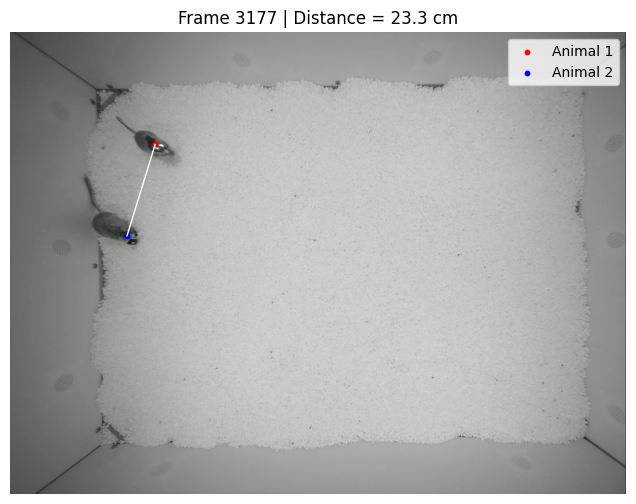

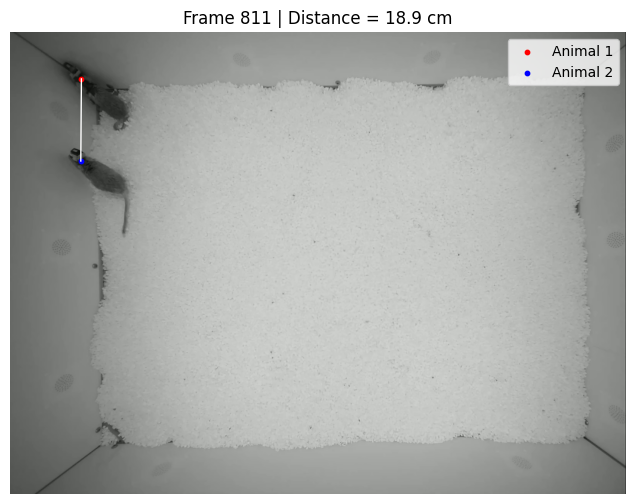

In [16]:
import cv2
import matplotlib.pyplot as plt

threshold = 0.4  # meters
selected_frames = [f for exp_no in frame_samples for f in frame_samples[exp_no] if f["dist"] < threshold]

import random
samples_to_plot = random.sample(selected_frames, min(5, len(selected_frames)))

for s in samples_to_plot:
    # load the frame from video
    cap = cv2.VideoCapture(s["vid"])
    cap.set(cv2.CAP_PROP_POS_FRAMES, s["frame"])
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Could not read frame {s['frame']} from {s['vid']}")
        continue

    # convert BGR to RGB for matplotlib
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,6))
    plt.imshow(frame)

    # overlay points
    plt.scatter(s["u1"], s["v1"], color='red', label='Animal 1', s=10)
    plt.scatter(s["u2"], s["v2"], color='blue', label='Animal 2', s=10)

    # line connecting the animals
    plt.plot([s["u1"], s["u2"]], [s["v1"], s["v2"]], 'white', linewidth=1)

    # annotate distance in cm
    distance_cm = s['dist'] * 100  # meters -> cm
    plt.title(f"Frame {s['frame']} | Distance = {distance_cm:.1f} cm")
    plt.axis('off')
    plt.legend()
    plt.show()

### Plotting trails for bouts on video

In [40]:
exps = [433]

In [47]:
import cv2
import numpy as np
import pandas as pd
from collections import deque, defaultdict
from scipy.io import wavfile
from scipy.signal import spectrogram

def rolling_spectrogram(audio, sr, window_sec=2.0, lo=-100, hi=0):
    # audio: 1D numpy array
    n_samples = audio.shape[0]
    window_samples = int(window_sec * sr)
    # pad if shorter than window
    if n_samples < window_samples:
        audio = np.pad(audio, (window_samples - n_samples, 0))
        n_samples = audio.shape[0]
    freqs, bins, Pxx = spectrogram(audio, fs=sr, nperseg=512, noverlap=256)
    Pxx_dB = np.flipud(10 * np.log10(Pxx + 1e-12))
    Pxx_dB = np.clip(Pxx_dB, lo, hi)
    img = ((Pxx_dB - lo)/(hi - lo + 1e-12) * 255).astype(np.uint8)
    return img

trail_length = 100
rolling_window_sec = 2.0  # length of rolling window in seconds
spec_height = 400
half_h = spec_height // 2

for exp_no in exps:
    for vid_path in videos[exp_no]:
        if  vid_path.split("\\")[1] not in ["idx_001","idx_003"]:
            continue
        # --- Load SLEAP & DAS as before ---
        slp_file = [j for j in slp[exp_no] if vid_path.split("\\")[1] in j][0]
        tracks = pd.read_csv(slp_file)
        tracks.columns = tracks.columns.str.replace(".", "_", regex=False)

        das_file = [j for j in das[exp_no] if vid_path.split("\\")[1] in j][0]
        vox_times = pd.read_csv(das_file)
        vox_rows = vox_times[vox_times["name"] == "vox"]
        vox_frames_dict = defaultdict(lambda: 0.0)
        for row in vox_rows.itertuples(index=False):
            start_frame = int(row.start_seconds * cam_fps)
            stop_frame = int(row.stop_seconds * cam_fps)
            for f in range(start_frame, stop_frame + 1):
                vox_frames_dict[f] = row.label

        # --- Load headmic ---
        headmic_files = [j for j in headmic[exp_no] if vid_path.split("\\")[1] in j]
        wavfiles = {}
        for file in headmic_files:
            if "118" in file:
                sr, wavfiles["118"] = wavfile.read(file)
            elif "35" in file:
                sr, wavfiles["35"] = wavfile.read(file)

        # --- Load video ---
        cap = cv2.VideoCapture(vid_path)
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps    = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        idx = vid_path.split("\\")[1]
        out_height = height + spec_height  # we'll resize spectrogram window to 200px
        out = cv2.VideoWriter(f"rolling_spec_trail_{exp_no}_{idx}.mp4",
                              cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, out_height))

        # --- Trails ---
        trail_animal1 = deque(maxlen=trail_length)
        trail_animal2 = deque(maxlen=trail_length)
        colour_animal1 = deque(maxlen=trail_length)
        colour_animal2 = deque(maxlen=trail_length)

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_idx = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
            overlay = frame.copy()
            vocal_label = vox_frames_dict[frame_idx]

            # --- Update trails ---
            temp_df = tracks[tracks["frame_idx"] == frame_idx]
            pos_animal1 = None
            pos_animal2 = None
            for row in temp_df.itertuples(index=False):
                if "118" in row.track:
                    pos_animal1 = (int(row.head_x), int(row.head_y))
                    trail_animal1.append(pos_animal1)
                    if vocal_label == 118.0:
                        colour_animal1.append((0,255,255))
                    else:
                        colour_animal1.append((0,0,255))
                elif "35" in row.track:
                    pos_animal2 = (int(row.head_x), int(row.head_y))
                    trail_animal2.append(pos_animal2)
                    if vocal_label == 35.0:
                        colour_animal2.append((0,255,255))
                    else:
                        colour_animal2.append((255,0,0))

            # Draw trails
            for (x, y), col in zip(trail_animal1, colour_animal1):
                cv2.circle(overlay, (x, y), radius=5, color=col, thickness=-1)
            for (x, y), col in zip(trail_animal2, colour_animal2):
                cv2.circle(overlay, (x, y), radius=5, color=col, thickness=-1)

            # Highlight vocalizing animal
            if vocal_label == 118.0 and pos_animal1:
                cv2.circle(overlay, pos_animal1, radius=12, color=(0,255,255), thickness=-1)
            elif vocal_label == 35.0 and pos_animal2:
                cv2.circle(overlay, pos_animal2, radius=12, color=(0,255,255), thickness=-1)

            # --- Compute rolling spectrogram for current frame ---
            current_time = frame_idx / fps
            window_start = max(0, int((current_time - rolling_window_sec) * sr))
            window_end   = min(int(current_time * sr), wavfiles["118"].shape[0])

            spec1 = rolling_spectrogram(wavfiles["118"][window_start:window_end], sr, window_sec=rolling_window_sec)
            spec2 = rolling_spectrogram(wavfiles["35"][window_start:window_end], sr, window_sec=rolling_window_sec)


            # Resize each separately
            spec1 = cv2.resize(spec1, (width, half_h))
            spec2 = cv2.resize(spec2, (width, half_h))

            spec1 = cv2.cvtColor(spec1, cv2.COLOR_GRAY2BGR)
            spec2 = cv2.cvtColor(spec2, cv2.COLOR_GRAY2BGR)

            cv2.putText(spec1, "Fluffy", (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)

            cv2.putText(spec2, "Neck", (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

            # Dynamic border colors
            color1 = (0,255,255) if vocal_label == 118.0 else (0,0,255)
            color2 = (0,255,255) if vocal_label == 35.0 else (255,0,0)

            cv2.rectangle(spec1, (0,0), (width-1, half_h-1), color1, 4)
            cv2.rectangle(spec2, (0,0), (width-1, half_h-1), color2, 4)

            spec_comb = np.vstack([spec1, spec2])

            # --- Add moving cursor at right edge ---
            cursor_x = spec_comb.shape[1] - 2
            cv2.line(spec_comb, (cursor_x, 0), (cursor_x, spec_comb.shape[0]-1),
                     color=(0,255,0), thickness=2)

            # --- Concatenate spectrogram above video frame ---
            combined_frame = np.vstack([spec_comb, overlay])
            out.write(combined_frame)

        cap.release()
        out.release()

In [ ]:
# import cv2
# import numpy as np
# import pandas as pd
# from collections import deque


# def write_spectrogram_img(audio, sr, lo=-70, hi=0):
#     freqs, bins, Pxx = spectrogram(audio, fs=sr, nperseg=512, noverlap=256)

#     # convert to dB and flip vertically for visualization
#     Pxx_dB = np.flipud(10 * np.log10(Pxx + 1e-12))

#     # clip and normalize
#     a = np.clip(Pxx_dB, lo, hi)
#     a = (a - lo) / (hi - lo + 1e-12)
#     a = (a * 255).astype(np.uint8)

#     return a 


# trail_length = 100  # number of frames to keep in trail

# for exp_no in exps:
#     for vid_path in videos[exp_no]:


#         # match SLEAP file
#         slp_file = [j for j in slp[exp_no] if vid_path.split("\\")[1] in j][0]
#         tracks = pd.read_csv(slp_file)
#         tracks.columns = tracks.columns.str.replace(".", "_", regex=False)


#         # load the das file
#         das_file = [j for j in das[exp_no] if vid_path.split("\\")[1] in j][0]
#         vox_times = pd.read_csv(das_file)
#         vox_rows = vox_times[vox_times["name"] == "vox"]

#         # load the headmic files
#         headmic_files = [j for j in headmic[exp_no] if vid_path.split("\\")[1] in j]
#         wavfiles = {}
#         # load both wav files
#         for file in headmic_files:
#             if "118" in file:
#                 sr , wavfiles["118"] = wavfile.read(file)
#             elif "35" in file:
#                 sr , wavfiles["35"] = wavfile.read(file)

#         # build dictionary: frame -> label of vocalizing animal
#         vox_frames_dict = defaultdict(lambda:0.0)
#         for row in vox_rows.itertuples(index=False):
#             start_frame = int(row.start_seconds * cam_fps)
#             stop_frame  = int(row.stop_seconds  * cam_fps)
#             for f in range(start_frame, stop_frame + 1):
#                 vox_frames_dict[f] = row.label  # label is the vocalizing animal

#         # get the frames for associated start and stop times and the label of the vocalizing animal


#         # Load video
#         cap = cv2.VideoCapture(vid_path)
#         width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#         height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
#         fps    = cap.get(cv2.CAP_PROP_FPS)
#         idx = vid_path.split("\\")[1]
#         out    = cv2.VideoWriter(f"vanishing_trail_output_{exp_no}_{idx}.mp4",
#                                  cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

#         # Keep recent positions for each animal
#         trail_animal1 = deque(maxlen=trail_length)
#         trail_animal2 = deque(maxlen=trail_length)

#         # keep the circle colour history too
#         colour_animal1 = deque(maxlen=trail_length)
#         colour_animal2 = deque(maxlen=trail_length)

#         # making a deque for wavefile data
#         spec_animal_1 = deque(maxlen=)
#         spec_animal_2 = deque(maxlen=)  

#         # Loop through frames
#         while True:
#             flag_118 = 0
#             flag_35 = 0
#             ret, frame = cap.read()
#             if not ret:
#                 break
#             frame_idx = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

#             # Get positions of animals in this frame
#             temp_df = tracks[tracks["frame_idx"] == frame_idx]
#             vocal_label = vox_frames_dict[frame_idx]
                
#             for row in temp_df.itertuples(index=False):
#                 if "118" in row.track:
#                     trail_animal1.append((int(row.head_x), int(row.head_y)))
#                     flag_118 = 1
#                     if vocal_label == 118.0:
#                         colour_animal1.append((0,255,255))
#                     else:
#                         colour_animal1.append((0,0,255))
#                 elif "35" in row.track:
#                     trail_animal2.append((int(row.head_x), int(row.head_y)))
#                     flag_35 = 1
#                     if vocal_label == 35.0:
#                         colour_animal2.append((0,255,255))
#                     else:
#                         colour_animal2.append((255,0,0))

#             # Draw trails for animal 1 (red)
#             for (x, y),colour in zip(trail_animal1,colour_animal1):
#                 cv2.circle(frame, (x, y), radius=5, color=colour, thickness=1)

#             # Draw trails for animal 2 (blue)
#             for (x, y),colour in zip(trail_animal2,colour_animal2):
#                 cv2.circle(frame, (x, y), radius=5, color=colour, thickness=1)

#             # ------------------------------
#             # Highlight the animal that vocalized
#             # ------------------------------
#             if vocal_label == 118.0 and flag_118==1:
#                 cv2.circle(overlay, trail_animal2[-1], radius=12, color=(0,255,255), thickness=-1)
#             elif vocal_label == 35.0 and flag_35==1:
#                 cv2.circle(overlay, trail_animal2[-1], radius=12, color=(0,255,255), thickness=-1)

#             # Write frame to output
#             out.write(frame)

#         cap.release()
#         out.release()
#         break
#     break

KeyboardInterrupt: 